<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/11_granica_split_analiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11 — Evaluacija modela na granicama train/test podjele

Provjera da li ResNet18 (finalni, odbranjeni model, `models/resnet18_transfer.pt`) bolje
predviđa slike koje se nalaze **na samoj granici** train/test podjele (prve slike test bloka
od 50 frejmova, do kojih se prelazi direktno iz susjednog train bloka) u odnosu na slike koje
su **najdalje** od te granice (poslednje slike istog test bloka). Analiza se radi nad svim
parovima susjednih blokova gdje je jedan train, a drugi test.

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.9 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:04<00:00, 92.8MB/s]



In [2]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!ls models

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 187 (delta 38), reused 13 (delta 3), pack-reused 112 (from 2)
Receiving objects: 100% (187/187), 279.33 MiB | 11.47 MiB/s, done.
Resolving deltas: 100% (87/87), done.
Updating files: 100% (24/24), done.
/content/Tom-and-Jerry-Character-Classification
cnn_scratch.pt		   resnet18_transfer.pt  svm_final.joblib
resnet18_transfer_10ep.pt  rf_final.joblib	 svm_scaler.joblib


### Rekonstrukcija `frame_num` i `block` kolona

`data_split.csv` čuva samo `filename, tom, jerry, class, split` — kolone `frame_num` i `block`
su bile privremene u `01_eda_split.ipynb` (korišćene samo da se napravi split), nisu sačuvane
u finalnom fajlu. Za ovu analizu su nam ponovo potrebne (treba nam znati koji frejmovi
pripadaju kom bloku od 50), pa ih računamo istom formulom kao u 01.

In [3]:
import pandas as pd

split_df = pd.read_csv('data_split.csv')
split_df['frame_num'] = split_df['filename'].str.extract(r'(\d+)').astype(int)
split_df['block'] = split_df['frame_num'] // 50

print(split_df['split'].value_counts())
print(split_df[['filename', 'frame_num', 'block', 'split']].head())
print("Broj jedinstvenih blokova:", split_df['block'].nunique())

split
train       3755
val          847
test         844
excluded      32
Name: count, dtype: int64
     filename  frame_num  block  split
0  frame0.jpg          0      0  train
1  frame1.jpg          1      0  train
2  frame2.jpg          2      0  train
3  frame3.jpg          3      0  train
4  frame4.jpg          4      0  train
Broj jedinstvenih blokova: 110


In [4]:
class_to_folder = {
    'neither': 'tom_jerry_0',
    'both': 'tom_jerry_1',
    'jerry': 'jerry',
    'tom': 'tom'
}

data_dir = '../data/tom_and_jerry/tom_and_jerry'

split_df['filepath'] = split_df.apply(
    lambda row: f"{data_dir}/{class_to_folder[row['class']]}/{row['filename']}", axis=1
)

import os
print(split_df['filepath'].iloc[0], os.path.exists(split_df['filepath'].iloc[0]))
print(split_df['filepath'].iloc[-1], os.path.exists(split_df['filepath'].iloc[-1]))

../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame0.jpg True
../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame5477.jpg True


Provjera da li je svaki blok "čist" (jedan split po bloku) i određivanje kom skupu pripada svaki blok.

In [5]:
non_excluded = split_df[split_df['split'] != 'excluded']
block_splits = non_excluded.groupby('block')['split'].unique()

mesoviti = block_splits[block_splits.apply(len) > 1]
print("Blokova sa mješovitim splitom:", len(mesoviti))
if len(mesoviti) > 0:
    print(mesoviti)

block_split_map = block_splits.apply(lambda x: x[0])
print(block_split_map.value_counts())

Blokova sa mješovitim splitom: 0
split
train    76
val      17
test     17
Name: count, dtype: int64


Traženje graničnih parova — test blokova koji imaju train blok odmah prije ili odmah poslije sebe.

In [6]:
train_blocks = set(block_split_map[block_split_map == 'train'].index)
test_blocks = set(block_split_map[block_split_map == 'test'].index)

granicni_parovi = []
for b in sorted(test_blocks):
    if (b - 1) in train_blocks:
        granicni_parovi.append({'test_block': b, 'granica_na': 'pocetku'})
    if (b + 1) in train_blocks:
        granicni_parovi.append({'test_block': b, 'granica_na': 'kraju'})

print("Broj graničnih parova:", len(granicni_parovi))
for p in granicni_parovi:
    print(p)

Broj graničnih parova: 24
{'test_block': 11, 'granica_na': 'pocetku'}
{'test_block': 11, 'granica_na': 'kraju'}
{'test_block': 16, 'granica_na': 'pocetku'}
{'test_block': 18, 'granica_na': 'kraju'}
{'test_block': 31, 'granica_na': 'pocetku'}
{'test_block': 31, 'granica_na': 'kraju'}
{'test_block': 33, 'granica_na': 'pocetku'}
{'test_block': 33, 'granica_na': 'kraju'}
{'test_block': 37, 'granica_na': 'pocetku'}
{'test_block': 44, 'granica_na': 'pocetku'}
{'test_block': 54, 'granica_na': 'pocetku'}
{'test_block': 54, 'granica_na': 'kraju'}
{'test_block': 65, 'granica_na': 'pocetku'}
{'test_block': 65, 'granica_na': 'kraju'}
{'test_block': 80, 'granica_na': 'kraju'}
{'test_block': 84, 'granica_na': 'pocetku'}
{'test_block': 84, 'granica_na': 'kraju'}
{'test_block': 88, 'granica_na': 'pocetku'}
{'test_block': 88, 'granica_na': 'kraju'}
{'test_block': 90, 'granica_na': 'pocetku'}
{'test_block': 90, 'granica_na': 'kraju'}
{'test_block': 96, 'granica_na': 'pocetku'}
{'test_block': 96, 'granic

Za svaki granični par izdvajamo N=5 slika najbližih granici i N=5 slika najdaljih od granice (unutar tog test bloka).

Napomena: test blok koji se nalazi IZMEĐU dva train bloka (train-test-train) pojavljuje se u dva para, pa se dio njegovih slika koristi i kao "blizu" (u odnosu na jednu granicu) i kao "daleko" (u odnosu na drugu granicu).

In [7]:
N = 5
redovi = []

for par in granicni_parovi:
    b = par['test_block']
    blok_slike = split_df[(split_df['block'] == b) & (split_df['split'] == 'test')].sort_values('frame_num')

    if len(blok_slike) < 2 * N:
        continue  # premalo slika u bloku za jasnu podjelu blizu/daleko

    if par['granica_na'] == 'pocetku':
        blizu, daleko = blok_slike.iloc[:N], blok_slike.iloc[-N:]
    else:
        blizu, daleko = blok_slike.iloc[-N:], blok_slike.iloc[:N]

    for _, row in blizu.iterrows():
        redovi.append({'filename': row['filename'], 'filepath': row['filepath'], 'class': row['class'],
                        'test_block': b, 'granica_na': par['granica_na'], 'pozicija': 'blizu'})
    for _, row in daleko.iterrows():
        redovi.append({'filename': row['filename'], 'filepath': row['filepath'], 'class': row['class'],
                        'test_block': b, 'granica_na': par['granica_na'], 'pozicija': 'daleko'})

granicna_analiza_df = pd.DataFrame(redovi)
print(granicna_analiza_df['pozicija'].value_counts())
print(granicna_analiza_df.head(10))

pozicija
blizu     120
daleko    120
Name: count, dtype: int64
       filename                                           filepath    class  \
0  frame550.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
1  frame551.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
2  frame552.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
3  frame553.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
4  frame554.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   
5  frame595.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   
6  frame596.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   
7  frame597.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   
8  frame598.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   
9  frame599.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   

   test_block granica_na pozicija  
0          11    pocetku    bli

Pravimo Dataset/DataLoader za tih 240 graničnih slika

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class_to_idx = {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class GranicnaDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        image = self.transform(image)
        label = class_to_idx[row['class']]
        return image, label

granicni_ds = GranicnaDataset(granicna_analiza_df, transform=transform)
granicni_loader = DataLoader(granicni_ds, batch_size=32, shuffle=False, num_workers=2)

print(len(granicni_ds))

240


Učitavamo arhitekturu i sačuvane težine finalnog ResNet18 modela i puštamo predikcije na tih 240 graničnih slika.

In [9]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load('models/resnet18_transfer.pt', map_location=device))
model = model.to(device)
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in granicni_loader:
        images = images.to(device)
        pred = model(images).argmax(1).cpu()
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

granicna_analiza_df['tacno'] = [idx_to_class[t] for t in y_true]
granicna_analiza_df['predikcija'] = [idx_to_class[p] for p in y_pred]
granicna_analiza_df['tacan_pogodak'] = granicna_analiza_df['tacno'] == granicna_analiza_df['predikcija']

print(granicna_analiza_df.head())

Device: cpu
       filename                                           filepath    class  \
0  frame550.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
1  frame551.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
2  frame552.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
3  frame553.jpg  ../data/tom_and_jerry/tom_and_jerry/tom/frame5...      tom   
4  frame554.jpg  ../data/tom_and_jerry/tom_and_jerry/tom_jerry_...  neither   

   test_block granica_na pozicija    tacno predikcija  tacan_pogodak  
0          11    pocetku    blizu      tom        tom           True  
1          11    pocetku    blizu      tom        tom           True  
2          11    pocetku    blizu      tom        tom           True  
3          11    pocetku    blizu      tom        tom           True  
4          11    pocetku    blizu  neither    neither           True  


Računamo tačnost predikcija odvojeno za grupu "blizu" i grupu "daleko", i po test bloku.

In [10]:
tacnost_po_poziciji = granicna_analiza_df.groupby('pozicija')['tacan_pogodak'].mean()
print("Tačnost po poziciji (blizu vs daleko):")
print(tacnost_po_poziciji)

print("\nBroj tačnih/netačnih po poziciji:")
print(granicna_analiza_df.groupby('pozicija')['tacan_pogodak'].value_counts())

Tačnost po poziciji (blizu vs daleko):
pozicija
blizu     0.933333
daleko    0.916667
Name: tacan_pogodak, dtype: float64

Broj tačnih/netačnih po poziciji:
pozicija  tacan_pogodak
blizu     True             112
          False              8
daleko    True             110
          False             10
Name: count, dtype: int64


Statistički test (Fisher's exact test) — provjera da li je razlika u tačnosti (blizu vs daleko) stvarna ili slučajna.

In [11]:
from scipy.stats import fisher_exact

tabela = pd.crosstab(granicna_analiza_df['pozicija'], granicna_analiza_df['tacan_pogodak'])
print(tabela)

odds_ratio, p_value = fisher_exact(tabela)
print(f"\np-vrijednost: {p_value:.4f}")

tacan_pogodak  False  True 
pozicija                   
blizu              8    112
daleko            10    110

p-vrijednost: 0.8072


**Zaključak**

Statistički test (Fisher's exact, p=0.8072) ne pokazuje značajnu razliku u tačnosti između slika blizu i daleko od granice — model radi podjednako dobro nezavisno od udaljenosti od granice podjele.

Tačnost po pojedinačnom graničnom paru (test_block + granica_na), blizu naspram daleko.

In [12]:
po_paru = granicna_analiza_df.groupby(['test_block', 'granica_na', 'pozicija'])['tacan_pogodak'].mean().unstack()
po_paru.columns.name = None
po_paru = po_paru.rename(columns={'blizu': 'tacnost_blizu', 'daleko': 'tacnost_daleko'})
po_paru['razlika'] = po_paru['tacnost_blizu'] - po_paru['tacnost_daleko']
print(po_paru)

                       tacnost_blizu  tacnost_daleko  razlika
test_block granica_na                                        
11         kraju                 1.0             1.0      0.0
           pocetku               1.0             1.0      0.0
16         pocetku               0.8             1.0     -0.2
18         kraju                 1.0             1.0      0.0
31         kraju                 1.0             0.4      0.6
           pocetku               0.4             1.0     -0.6
33         kraju                 0.8             0.8      0.0
           pocetku               0.8             0.8      0.0
37         pocetku               1.0             1.0      0.0
44         pocetku               1.0             0.6      0.4
54         kraju                 1.0             1.0      0.0
           pocetku               1.0             1.0      0.0
65         kraju                 1.0             1.0      0.0
           pocetku               1.0             1.0      0.0
80      

Grafik — poređenje tačnosti blizu vs daleko, ukupno i po pojedinačnom paru.

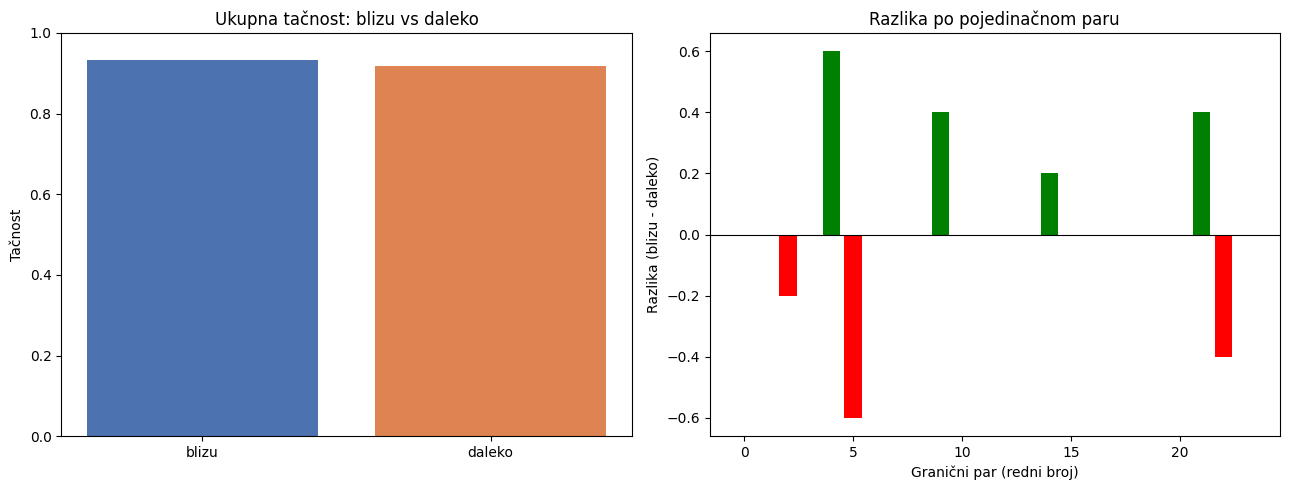

In [13]:
import matplotlib.pyplot as plt
import os

os.makedirs('results/11_granica_split_analiza', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['blizu', 'daleko'], [tacnost_po_poziciji['blizu'], tacnost_po_poziciji['daleko']], color=['#4C72B0', '#DD8452'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Tačnost')
axes[0].set_title('Ukupna tačnost: blizu vs daleko')

axes[1].bar(range(len(po_paru)), po_paru['razlika'], color=['green' if x > 0 else 'red' for x in po_paru['razlika']])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Granični par (redni broj)')
axes[1].set_ylabel('Razlika (blizu - daleko)')
axes[1].set_title('Razlika po pojedinačnom paru')

plt.tight_layout()
plt.savefig('results/11_granica_split_analiza/grafik_granica.png', dpi=150, bbox_inches='tight')
plt.show()

Čuvamo detaljne rezultate, tabelu po paru i sažetak kao CSV fajlove (za push na repo).

In [14]:
granicna_analiza_df.to_csv('results/11_granica_split_analiza/detaljni_rezultati.csv', index=False)
po_paru.to_csv('results/11_granica_split_analiza/rezultati_po_paru.csv')

sazetak = pd.DataFrame({
    'pozicija': ['blizu', 'daleko'],
    'tacnost': [tacnost_po_poziciji['blizu'], tacnost_po_poziciji['daleko']],
    'broj_slika': [120, 120],
    'p_vrijednost_fisher': [p_value, p_value]
})
sazetak.to_csv('results/11_granica_split_analiza/sazetak.csv', index=False)

print("Sačuvano.")

Sačuvano.


### Zaključak

- Pronađeno 24 granična para (susjedni blokovi od 50 frejmova gdje je jedan train, a drugi test).
- Tačnost na slikama blizu granice: **93.3%** (112/120); tačnost na slikama daleko od granice: **91.7%** (110/120).
- Statistički test (Fisher's exact, p=0.8072) ne pokazuje značajnu razliku — ova mala razlika je u granicama
  slučajnog šuma, ne dokaz stvarnog efekta.
- Poređenje po pojedinačnom paru dodatno potvrđuje ovo: razlike idu u OBA pravca (npr. blok 31 ima +0.6 u jednom
  paru, a -0.6 u drugom), bez dosljednog obrasca u korist slika blizu granice.
- **Zaključak:** nema dokaza da položaj slike u odnosu na granicu train/test podjele (blok od 50 frejmova) utiče
  na tačnost predikcija finalnog ResNet18 modela.

In [15]:
!git add results/11_granica_split_analiza/
!git commit -m "Dodaj analizu granica train/test podjele (notebook 11) - rezultati i grafik"
!git push

[main 395dee6] Dodaj analizu granica train/test podjele (notebook 11) - rezultati i grafik
 4 files changed, 269 insertions(+)
 create mode 100644 results/11_granica_split_analiza/detaljni_rezultati.csv
 create mode 100644 results/11_granica_split_analiza/grafik_granica.png
 create mode 100644 results/11_granica_split_analiza/rezultati_po_paru.csv
 create mode 100644 results/11_granica_split_analiza/sazetak.csv
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 40.10 KiB | 5.01 MiB/s, done.
Total 8 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification.git
   df55cd9..395dee6  main -> main
